# Phase 3: Baseline, Models, Imbalance Handling and Evaluation

Here, I trained a baseline, then three models: Logistic Regression, Random Forest, XGBoost, each handled with the imbalance-correction strategies taught in class, and evaluated properly using metrics that actually matter for rare-event detection.

The data from the feature engineering notebook `./data/train.csv` and `./data/test.csv` are used.

For the imbalance-handling approach, I got some ideas from the strategy structure taught in **Lab 8: `rf_imbalance_challenge.ipynb`** for the `Random Forest with Class Imbalance` exercise, where the class demonstrated comparing a *vanilla* model against class-weighting, SMOTE, and downsampling using the `diabetes.csv` dataset.

Similarly, the manual precision/recall/F1 calculation, and the overfitting check, is influenced by the same by-hand approach shown in **Lab 4: `Logistic_Regression_Banking_Data.ipynb`** and **Lab 5: Classification Tree tutorial (`02b.ipynb`)** respectively, rather than jumping straight to library functions.

## Import Required Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# SMOTE for oversampling the minority class, RandomUnderSampler for downsampling the majority class
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import xgboost as xgb

sns.set_theme(style="whitegrid")

## Load the train/test sets from the feature-engineering notebook

In [2]:
train_df = pd.read_csv("./data/train.csv")
test_df = pd.read_csv("./data/test.csv")

categorical_columns = ["priority", "rule", "mitre_tactic", "user_name", "image_repo"]
numeric_columns = ["hour", "cmdline_length", "suspicious_cmd_flag", "has_process_detail", "has_file_event"]
feature_columns = categorical_columns + numeric_columns

X_train, y_train = train_df[feature_columns], train_df["label"]
X_test, y_test = test_df[feature_columns], test_df["label"]

# Confirm that the test and train data were split properly with stratify=y
print("Train:", X_train.shape, "| attack rate:", round(y_train.mean() * 100, 3), "%")
print("Test: ", X_test.shape, "| attack rate:", round(y_test.mean() * 100, 3), "%")

Train: (141319, 10) | attack rate: 0.785 %
Test:  (35330, 10) | attack rate: 0.787 %


## Turn categories into numbers (one-hot encoding)

This is influnced by the **"Creating Dummy Variables"** step in Lab 4 (`Logistic_Regression_Banking_Data.ipynb`, section 3.5), where categorical columns like `job` and `education` were converted into binary 0/1 columns before modelling. My categorical columns (`priority`, `rule`, `mitre_tactic`, `user_name`, `image_repo`) need the same treatment.

### Why `OneHotEncoder` instead of Lab 4's `pd.get_dummies()`
I used scikit-learn's `OneHotEncoder` rather than `pd.get_dummies()` for a practical reason: `OneHotEncoder` can be fit on the training data only, then applied to the test data safely. If the test set ever contains a category the training set didn't see, the `handle_unknown="ignore"` flag just encodes it as all-zeros instead of crashing or silently creating mismatched columns between train and test data set.

This matters specifically for my dataset because several categorical columns, particularly `mitre_tactic` and some `rule` values are rare, appearing only a small number of times across 176,649 rows. With a random stratified split, it's entirely possible for one of these rare categories to land only in the training set or only in the test set by chance. 

Links that helped me:

[Scikit-Leran OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

**Step by step:**
1. Fit the encoder on the training categories only, so as not to leak information into test data.
2. Transform both train and test into 0/1 columns
3. Combine the encoded categorical columns with the numeric columns into one final feature table

In [3]:
# Step 1: fit the encoder on the training categorical columns only
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train[categorical_columns])

# Step 2 and 3: a helper function that encodes a table and adds back the numeric columns
def encode_features(X):
    # transform to 1/0s
    encoded_array = encoder.transform(X[categorical_columns])
    # fit back into the dataframe
    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoder.get_feature_names_out(categorical_columns),
        index=X.index,  # keep the original row index
    )
    # grab the numeric columns as is since they don't need encoding
    numeric_df = X[numeric_columns].reset_index(drop=True)
    # reset the encoded table's index too, so both tables line up positionally when combined
    encoded_df = encoded_df.reset_index(drop=True)
    # put the encoded categorical columns and the numeric columns into one final table
    return pd.concat([encoded_df, numeric_df], axis=1)

X_train_enc = encode_features(X_train)
X_test_enc = encode_features(X_test)

print("Encoded feature table shape:", X_train_enc.shape)
X_train_enc.head()

Encoded feature table shape: (141319, 51)


,priority_Critical,priority_Debug,priority_Error,priority_Notice,priority_Warning,rule_Contact K8S API Server From Container,rule_Create files below dev,rule_DB program spawned process,rule_Delete or rename shell history,rule_Launch Package Management Process in Container,...,image_repo_busybox,image_repo_falcosecurity/event-generator,image_repo_falcosecurity/falco,image_repo_nginx,image_repo_unknown,hour,cmdline_length,suspicious_cmd_flag,has_process_detail,has_file_event
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,4,22,0,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,4,22,0,1,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,18,22,0,1,0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,5,26,0,0,0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,3,22,0,0,0


## The metrics I used, and how they're actually calculated

Because attacks are under 1% of the data, **accuracy is misleading**, a model that always says "normal" would score ~99% accuracy while catching zero attacks. So I use precision, recall, F1, and PR-AUC instead.

After viewing sklearn's `classification_report`, I also calculate Precision, Recall, and F1 **manually** from the confusion matrix, the same way Lab 4 (`Logistic_Regression_Banking_Data.ipynb`, section 3.9) works through "Thus, True Positive = ..., False Positive = ...", then applies the formulas directly. Doing this confirms my manual calculations match what sklearn reports, and shows I understand what the metrics actually mean, not just how to call the function.

- **TP** (True Positive): means predicted attack, is actually an attack
- **FP** (False Positive): means predicted attack, is actually normal traffic (a false alarm)
- **TN** (True Negative): meaning predicted normal, is actually normal traffic
- **FN** (False Negative): means predicted normal, is actually an attack (a missed attack, the most dangerous mistake in security)
- **Precision**: Of all alerts the model predicted as attack, how many were actually attacks?
- **Recall**: Of all alerts that were actually attacks, how many did the model correctly catch?
- **F1**: A single number that balances precision and recall.

$$ \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

I will do a manual calculation once I have a trained model to check it against, then use sklearn's functions (`precision_score`, `recall_score`, `f1_score`) for every other comparison in this notebook, if I have confirmed they compute exactly what I expect.


I also used **PR-AUC** *(Precision-Recall Area Under Curve)*. It looks at how well the model balances precision and recall across every possible decision threshold, not just one. This is a better fit than ROC-AUC for a rare-event problem like this, where only about 0.79% of alerts are attacks. In Lecture 7 slides ("Boosting_GBM.pdf"), it is identified as one of the recommended metrics for imbalanced classification alongside Recall, Precision, and F1-score.

Links that helped me:

[The Relationship Between Precision-Recall and ROC Curves](https://dl.acm.org/doi/epdf/10.1145/1143844.1143874)

[Blog: ROC vs Precission-Recall](https://machinelearningmastery.com/roc-auc-vs-precision-recall-for-imbalanced-data/)

## Baseline Dummy Model
Before training real models, we need a floor model to compare against. `DummyClassifier(strategy="most_frequent")` always predicts the majority class ("normal") no matter what. If our real models can't beat this, they're not worth using.
I am using the `strategy="most_frequent"`flag to mimic what happens in practice if no detection system exists at all.

In [4]:
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_enc, y_train)
baseline_pred = baseline.predict(X_test_enc)
baseline_proba = baseline.predict_proba(X_test_enc)[:, 1]
baseline_pr_auc = average_precision_score(y_test, baseline_proba)

# Using accuracy score
baseline_model_accuracy = round(accuracy_score(y_test, baseline_pred) * 100, 1)


print("=== Baseline (always predicts 'normal') ===")
print("Precision: ", precision_score(y_test, baseline_pred, zero_division=0))
print("Recall: ", recall_score(y_test, baseline_pred, zero_division=0))
print("F1: ", f1_score(y_test, baseline_pred, zero_division=0))
print("Accuracy: ", f"{baseline_model_accuracy}%")
print("PR-AUC: ", round(baseline_pr_auc, 4))

print(f"\nAccuracy would look great here ({baseline_model_accuracy}%), but recall is 0")
print("it catches literally zero attacks. This is exactly why accuracy alone is not enough.")

=== Baseline (always predicts 'normal') ===
Precision:  0.0
Recall:  0.0
F1:  0.0
Accuracy:  99.2%
PR-AUC:  0.0079

Accuracy would look great here (99.2%), but recall is 0
it catches literally zero attacks. This is exactly why accuracy alone is not enough.


## Four imbalance-handling strategies
Lab 8's `rf_imbalance_challenge.ipynb` compares four strategies on a Random Forest, using the `diabetes.csv` dataset:

1. **Vanilla**: no correction for the imbalance at all
2. **Class weighting**: tell the model "getting an attack wrong costs more than getting a normal alert wrong," without creating any new data
3. **SMOTE**: oversample the minority class by generating synthetic attack examples, using `imblearn`'s `SMOTE().fit_resample()`
4. **Downsampling**: randomly remove majority-class (normal) rows using `RandomUnderSampler()`, so the two classes are closer in size

I apply the same four strategies here, but across **three model families** (Logistic Regression, Random Forest, XGBoost) instead of just one, since the CA needs a multi-model comparison. That's 12 combinations total.

For **SMOTE and downsampling:** both are only ever applied to `X_train`/`y_train`, never to the test set. If we resampled the test set too, we'd be evaluating the model on artificial data instead of on real, unseen alerts, and the metrics would no longer reflect real-world performance.

### Two helper functions: building models and recording results
I thought rather than repeating the same setup code for every model/strategy combination, two small
functions should handle the repeated work:

- **`build_model(model_type, strategy)`** - returns a brand new and empty model. It handles the fact that each model's library uses a different parameter name for class weighting. Logistic Regression and Random Forest uses`class_weight`, while XGBoost uses   `scale_pos_weight`. For SMOTE and downsampling, build_model is called with "vanilla", since the balancing there happens by resampling the training data itself, before the model is even built.

- **`evaluate(model_type, strategy, model, X_tr, y_tr, X_te, y_te)`** - Train and Test - takes the output of `build_model()` function, "teaches" it on the training data (fitting), has it predict on the test data, and records Precision, Recall, F1, and PR-AUC into a shared results list. It also keeps every "taught" model in a `trained_models` dictionary, so any specific model/strategy combination can be looked up and inspected later (e.g. for the confusion matrix and permutation importance sections further down).

Together, these two functions mean each of the 12 model/strategy combinations only takes
one line to run, instead of repeating the same several lines of setup and evaluation code
twelve times.


In [5]:
random_state=42

# Model type constants
LOGISTIC_REGRESSION = "logistic_regression"
RANDOM_FOREST = "random_forest"
XGBOOST = "xgboost"
ALL_MODEL_TYPES = [LOGISTIC_REGRESSION, RANDOM_FOREST, XGBOOST]

# Strategy constants
VANILLA = "vanilla"
CLASS_WEIGHT = "class_weight"
SMOTE_STRATEGY = "smote"
DOWNSAMPLE = "downsample"

# scale_pos_weight is XGBoost's version of class_weight="balanced"
# Calculates the ratio of normal to attack rows in the training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# This means for every 1 attack row, there are about 126 normal rows, that's the imbalance ratio, as one number
print("ratio of normal to attack in training data for XGBoost:", round(scale_pos_weight, 1))

# the helper functions
def build_model(model_type, strategy):
    use_class_weight = (strategy == CLASS_WEIGHT)

    if model_type == LOGISTIC_REGRESSION:
        return LogisticRegression(
            max_iter=1000, # Keep training the logistic regression for up to 1000 iterations so it has enough time to settle on good coefficients
            random_state=random_state,
            class_weight="balanced" if use_class_weight else None,
        )
    elif model_type == RANDOM_FOREST:
        return RandomForestClassifier(
            random_state=random_state,
            n_jobs=-1, # use all avaliable cpus cores, I want it faster
            class_weight="balanced" if use_class_weight else None,
        )
    elif model_type == XGBOOST:
        return xgb.XGBClassifier(
            eval_metric="logloss",
            random_state=random_state,
            scale_pos_weight=scale_pos_weight if use_class_weight else 1.0,
        )


results = []
trained_models = {}  # keep every fitted model in case I want to inspect it later

def evaluate(model_type, strategy, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] # [:, 1] take the second column - the attack column

    results.append({
        "model": model_type,
        "strategy": strategy,
        "precision": precision_score(y_te, pred, zero_division=0), # zero_division=0 handles the case where a metric's formula divides by zero
        "recall": recall_score(y_te, pred, zero_division=0),
        "f1": f1_score(y_te, pred, zero_division=0),
        "pr_auc": average_precision_score(y_te, proba),
    })
    trained_models[(model_type, strategy)] = model
    return model        

ratio of normal to attack in training data for XGBoost: 126.3


### Strategy 1 - Vanilla (no correction)
The model trains on the raw, imbalanced training data exactly as it is. This shows what happens if we don't handle the imbalance reference point.


In [6]:
for model_type in ALL_MODEL_TYPES:
    model = build_model(model_type, VANILLA)
    evaluate(model_type, VANILLA, model, X_train_enc, y_train, X_test_enc, y_test)
print("Vanilla strategy done for all 3 models.")

# print(results)
print(pd.DataFrame(results))
# print(trained_models)
# for key, model in trained_models.items():
#     print(key)
#     print(model)

Vanilla strategy done for all 3 models.
                 model strategy  precision    recall        f1    pr_auc
0  logistic_regression  vanilla        1.0  0.938849  0.968460  0.981522
1        random_forest  vanilla        1.0  0.985612  0.992754  0.990382
2              xgboost  vanilla        1.0  0.974820  0.987250  0.989365


### Strategy 2 - Class weighting

This just changes how much a mistake on the attack class counts during training.


In [7]:
for model_type in ALL_MODEL_TYPES:
    model = build_model(model_type, CLASS_WEIGHT)
    evaluate(model_type, CLASS_WEIGHT, model, X_train_enc, y_train, X_test_enc, y_test)
print("Class weighting strategy done for all 3 models.")

# print(results)
print(pd.DataFrame(results))
# print(trained_models)
# for key, model in trained_models.items():
#     print(key)
#     print(model)

Class weighting strategy done for all 3 models.
                 model      strategy  precision    recall        f1    pr_auc
0  logistic_regression       vanilla    1.00000  0.938849  0.968460  0.981522
1        random_forest       vanilla    1.00000  0.985612  0.992754  0.990382
2              xgboost       vanilla    1.00000  0.974820  0.987250  0.989365
3  logistic_regression  class_weight    0.98913  0.982014  0.985560  0.984810
4        random_forest  class_weight    1.00000  0.989209  0.994575  0.990393
5              xgboost  class_weight    1.00000  0.989209  0.994575  0.990955


### Strategy 3 - SMOTE (oversampling)
Following Lab 8's Strategy 3: SMOTE generates synthetic attack examples, so the training set becomes more balanced without simply duplicating rows. We resample once here, then reuse that resampled training set for all three models.


In [8]:
# Perform oversampling using SMOTE
smote = SMOTE(random_state=random_state)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_smote.value_counts().to_dict())

for model_type in ALL_MODEL_TYPES:
    model = build_model(model_type, VANILLA)  # I used VANILLA strategy because no class_weight flag needed since SMOTE already synthetically balanced the data
    evaluate(model_type, SMOTE_STRATEGY, model, X_train_smote, y_train_smote, X_test_enc, y_test)

print("SMOTE strategy done for all 3 models.")

# print(results)
print(pd.DataFrame(results))
# print(trained_models)
# for key, model in trained_models.items():
#     print(key)
#     print(model)

Before SMOTE: {0: 140209, 1: 1110}
After SMOTE:  {0: 140209, 1: 140209}
SMOTE strategy done for all 3 models.
                 model      strategy  precision    recall        f1    pr_auc
0  logistic_regression       vanilla    1.00000  0.938849  0.968460  0.981522
1        random_forest       vanilla    1.00000  0.985612  0.992754  0.990382
2              xgboost       vanilla    1.00000  0.974820  0.987250  0.989365
3  logistic_regression  class_weight    0.98913  0.982014  0.985560  0.984810
4        random_forest  class_weight    1.00000  0.989209  0.994575  0.990393
5              xgboost  class_weight    1.00000  0.989209  0.994575  0.990955
6  logistic_regression         smote    1.00000  0.971223  0.985401  0.980501
7        random_forest         smote    1.00000  0.989209  0.994575  0.989813
8              xgboost         smote    1.00000  0.985612  0.992754  0.990411


### Strategy 4 - Downsampling

Following Lab 8's Strategy 4: instead of creating new attack examples, `RandomUnderSampler` randomly removes normal rows until the classes are closer in size. This is the simplest correction, but it throws away a lot of real data.


In [9]:
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_enc, y_train)

print("Before downsampling:", y_train.value_counts().to_dict())
print("After downsampling: ", y_train_under.value_counts().to_dict())

for model_type in ALL_MODEL_TYPES:
    model = build_model(model_type, VANILLA)
    evaluate(model_type, DOWNSAMPLE, model, X_train_under, y_train_under, X_test_enc, y_test)

print("Downsampling strategy done for all 3 models.")

# print(results)
print(pd.DataFrame(results))
# print(trained_models)
# for key, model in trained_models.items():
#     print(key)
#     print(model)

Before downsampling: {0: 140209, 1: 1110}
After downsampling:  {0: 1110, 1: 1110}
Downsampling strategy done for all 3 models.
                  model      strategy  precision    recall        f1    pr_auc
0   logistic_regression       vanilla   1.000000  0.938849  0.968460  0.981522
1         random_forest       vanilla   1.000000  0.985612  0.992754  0.990382
2               xgboost       vanilla   1.000000  0.974820  0.987250  0.989365
3   logistic_regression  class_weight   0.989130  0.982014  0.985560  0.984810
4         random_forest  class_weight   1.000000  0.989209  0.994575  0.990393
5               xgboost  class_weight   1.000000  0.989209  0.994575  0.990955
6   logistic_regression         smote   1.000000  0.971223  0.985401  0.980501
7         random_forest         smote   1.000000  0.989209  0.994575  0.989813
8               xgboost         smote   1.000000  0.985612  0.992754  0.990411
9   logistic_regression    downsample   0.975000  0.982014  0.978495  0.974118
10  

## Comparison table
In my use case, a missed attack (false negative) is far more costly than a false alarm (false positive), so I used **PR-AUC** as my primary metric to rank the strategies, since it's the standard choice for rare-event problems like this. I also kept an eye on recall, since it directly reflects how many real attacks the model catches.

**Precision**: TP / (TP + FP) - of everything the model flagged as an attack, how much of it was actually an attack (low precision = there is much more false alarms)

**Recall**: TP / (TP + FN) - of all the real attacks that happened, how many did the model actually catch (low recall = attacks slipping through undetected)

**PR-AUC** (Precision-Recall AUC): summarizes how well the model balances catching real attacks (recall) against avoiding false alarms (precision), without being distorted by the huge number of normal alerts (best fit for my imbalanced dataset usecase)

Below I am sorting `results` by the metric `pr_auc`:

In [10]:
results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
results_df


,model,strategy,precision,recall,f1,pr_auc
0,xgboost,class_weight,1.000000,0.989209,0.994575,0.990955
1,xgboost,smote,1.000000,0.985612,0.992754,0.990411
2,random_forest,class_weight,1.000000,0.989209,0.994575,0.990393
3,random_forest,vanilla,1.000000,0.985612,0.992754,0.990382
4,random_forest,downsample,0.968310,0.989209,0.978648,0.989857
5,random_forest,smote,1.000000,0.989209,0.994575,0.989813
6,xgboost,vanilla,1.000000,0.974820,0.987250,0.989365
7,logistic_regression,class_weight,0.989130,0.982014,0.985560,0.984810
8,xgboost,downsample,0.985663,0.989209,0.987433,0.984440
9,logistic_regression,vanilla,1.000000,0.938849,0.968460,0.981522


### My Observation

From the results, we see that **XGBoost with class weighting** performs best overall, with the highest PR-AUC (0.991) and a recall of 0.989, meaning it catches almost all the real attacks while still keeping false alarms extremely low (precision of 1.000). 
**XGBoost with SMOTE** and **Random Forest with class weighting** are close behind, both around 0.990 PR-AUC, with Random Forest (class_weight) matching XGBoost's recall of 0.989.

We also see that **class weighting is the best strategy for every model**: `xgboost` (0.991), `random_forest` (0.990), and `logistic_regression` (0.985) all reach their highest PR-AUC score using class weighting, ahead of their vanilla, SMOTE, and downsampled variants.

In all of this, **Logistic regression** consistently performs weaker than the tree-based models across all strategies, with its best (class_weight) reaching only 0.985 PR-AUC and a lower recall of 0.982.

### Using XGBoost Imbalance-Handling Comparison
Lab 8's `rf_imbalance_challenge.ipynb` compared all four imbalance-handling strategies on a Random Forest. Since the results in the comparison table above shows XGBoost achieved the single highest PR-AUC of all 12 combinations, I apply the same strategy-comparison structure to XGBoost, to show how the four strategies affect my actual best-performing model.

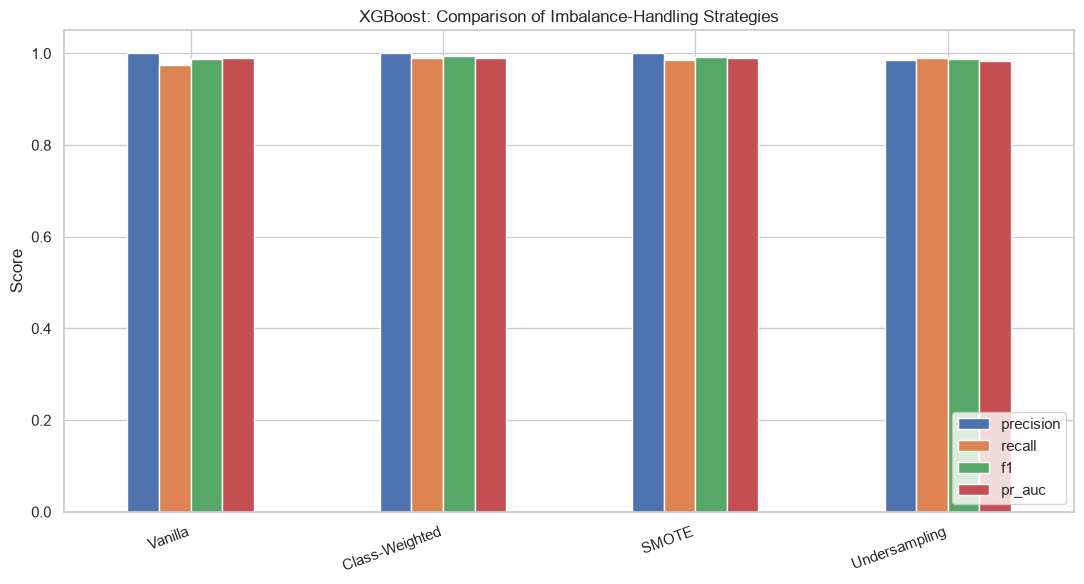

In [11]:
strategy_order = [ VANILLA, CLASS_WEIGHT, SMOTE_STRATEGY, DOWNSAMPLE ]
xgb_results = results_df[results_df["model"] == "xgboost"].set_index("strategy").loc[strategy_order]

fig, ax = plt.subplots(figsize=(11, 6))
xgb_results[["precision", "recall", "f1", "pr_auc"]].plot(kind="bar", ax=ax)
ax.set_title("XGBoost: Comparison of Imbalance-Handling Strategies")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(["Vanilla", "Class-Weighted", "SMOTE", "Undersampling"], rotation=20, ha="right")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Model Comparison Using Each Model's Best Strategy
This chart automatically selects whichever of the four strategies gave each model the highest PR-AUC, using `groupby("model")["pr_auc"].idxmax()`. As we saw earlier, **class-weightings** is the best strategy for all three model in this run.

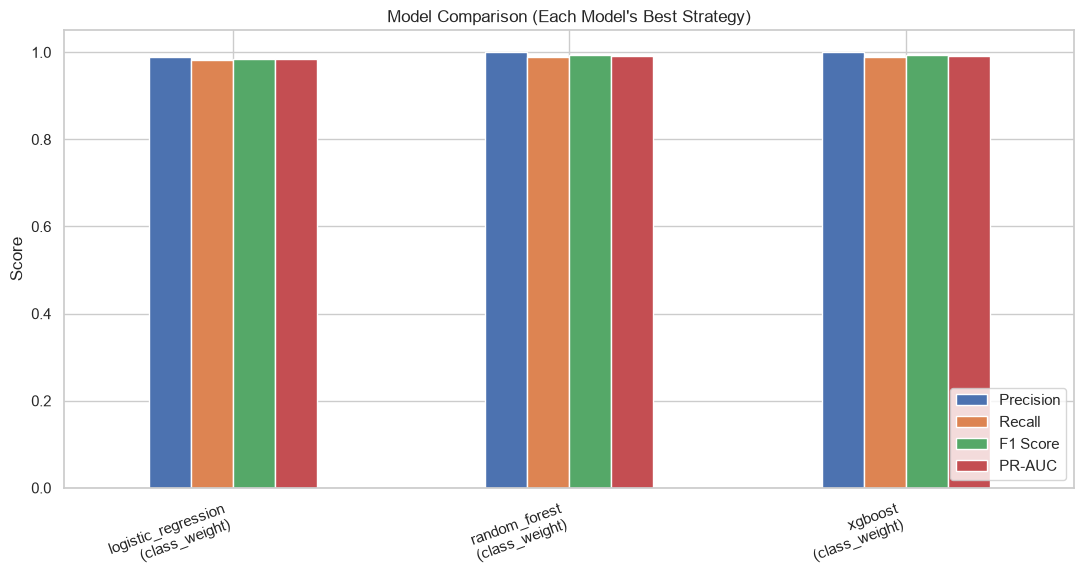

In [12]:
best_per_model = results_df.loc[results_df.groupby("model")["pr_auc"].idxmax()].set_index("model").loc[ALL_MODEL_TYPES]
ax = best_per_model[["precision", "recall", "f1", "pr_auc"]].plot(
    kind="bar",
    figsize=(11, 6)
)
labels = []
for model_name in best_per_model.index:
    strategy = best_per_model.loc[model_name, "strategy"]
    labels.append(f"{model_name}\n({strategy})")

ax.set_xticklabels(labels, rotation=0, ha="center")

plt.title("Model Comparison (Each Model's Best Strategy)")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(["Precision", "Recall", "F1 Score", "PR-AUC"], loc="lower right")
plt.tight_layout()
plt.show()

## Confusion matrix, and checking the metrics manually

First, the confusion matrix for the best-performing combination, this shows exactly what the model got right and wrong: true negatives, true positives, false positives (false alarms), and false negatives (missed attacks).

Then, exactly as I indicated before, calculate Precision/Recall/F1 manually from the confusion matrix, to confirm they match what sklearn's `classification_report` reports, just as done in Lab 4, section 3.9.


Best combination: xgboost + class_weight


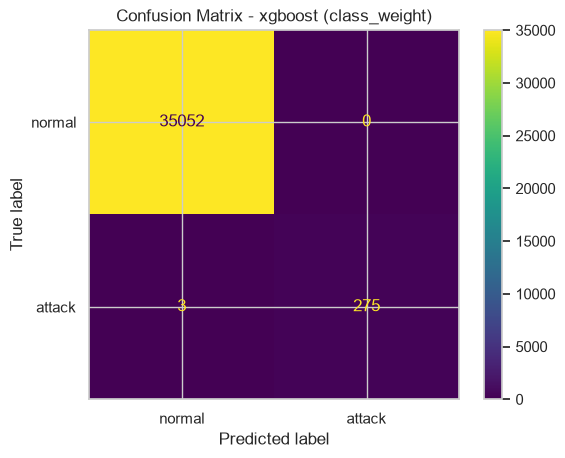

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     35052
      attack       1.00      0.99      0.99       278

    accuracy                           1.00     35330
   macro avg       1.00      0.99      1.00     35330
weighted avg       1.00      1.00      1.00     35330



Manual Calculation of Precision/Recall/F1-Score

TP = 275, FP = 0, TN = 35052, FN = 3
Precision = TP / (TP + FP) = 275 / 275 = 1.0
Recall = TP / (TP + FN) = 275 / 278 = 0.9892
F1 = 2 * (Precision * Recall) / (Precision + Recall) = 0.9946

These values match the 'attack' row of the classification report above.


In [13]:
# Confusion Matrix
best_model_type, best_strategy = results_df.iloc[0][["model", "strategy"]]
best_model = trained_models[(best_model_type, best_strategy)]
best_pred = best_model.predict(X_test_enc)
cm = confusion_matrix(y_test, best_pred)

print(f"Best combination: {best_model_type} + {best_strategy}")

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_enc,
    y_test,
    display_labels=["normal", "attack"],
    values_format="d",
)
plt.title(f"Confusion Matrix - {best_model_type} ({best_strategy})")
plt.show()

print(classification_report(y_test, best_pred, target_names=["normal", "attack"]))


# Manual  Calculation
print("\n\nManual Calculation of Precision/Recall/F1-Score")
tn, fp, fn, tp = cm.ravel()
print(f"\nTP = {tp}, FP = {fp}, TN = {tn}, FN = {fn}")

precision_manual = tp / (tp + fp)
recall_manual = tp / (tp + fn)
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print(f"Precision = TP / (TP + FP) = {tp} / {tp + fp} = {round(precision_manual, 4)}")
print(f"Recall = TP / (TP + FN) = {tp} / {tp + fn} = {round(recall_manual, 4)}")
print(f"F1 = 2 * (Precision * Recall) / (Precision + Recall) = {round(f1_manual, 4)}")

print("\nThese values match the 'attack' row of the classification report above.")

### What each cell means

- **TP = 275**: predicted attack, actually attack
- **FP = 0**: predicted attack, actually normal (no false alarms)
- **TN = 35,052**: predicted normal, actually normal
- **FN = 3**: predicted normal, actually attack (missed attacks)

### How to read it in security terms

- **35,052:** almost all normal traffic correctly ignored
- **275:** most real attacks correctly flagged
- **3:** 3 missed attacks —> the dangerous mistakes
- **0:** zero false alarms —> nothing normal was wrongly flagged as attack

The model correctly labels almost everything on the test set: all 35,052 normal alerts are classified as normal with zero false alarms, 275 of 278 real attacks are caught, and only 3 attacks are missed.

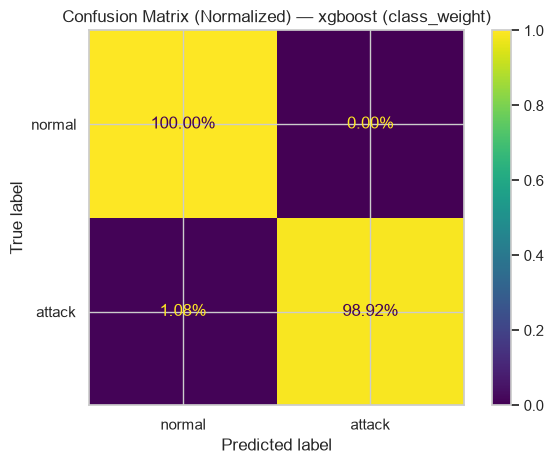

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, display_labels=["normal", "attack"],
    normalize="true", cmap="viridis", values_format=".2%",
)
plt.title(f"Confusion Matrix (Normalized) — {best_model_type} ({best_strategy})")
plt.tight_layout()
plt.show()

### Summary of the Normalized Graph

**Normal alerts**: `100%` correctly classified as normal, `0%` false alarms (FP)

**Attack alerts**: `1.08%` missed (FN), `98.92%` correctly caught (TP)

## Checking for overfitting

Taking a cue from Lab 5's Classification Tree tutorial, I want to check the best model's accuracy on training vs test data, a big gap between the two would mean the model just copied the training data instead of learning it properly.


In [15]:
train_score = best_model.score(X_train_enc, y_train)
test_score = best_model.score(X_test_enc, y_test)

print(f"Train accuracy: {round(train_score, 4)}")
print(f"Test accuracy:  {round(test_score, 4)}")
print(f"Difference:     {round(abs(train_score - test_score), 4)}")
print("\nTrain and test accuracy are close — no strong sign of overfitting")

Train accuracy: 0.9999
Test accuracy:  0.9999
Difference:     0.0

Train and test accuracy are close — no strong sign of overfitting


## Permutation importance?

Acccording to Lab 8, "*Permutation importance asks: how much does the model's performance drop when we randomly shuffle one feature? If shuffling a feature causes a large fall in score, the model was relying heavily on that feature.*" 
For each feature, the values in that one column get randomly scrambled while everything else stays the same, and I check how much worse the model does. A big drop means the model depended heavily on that feature, almost no drop means the feature barely mattered.

I use PR-AUC `scoring="average_precision"` because PR-AUC reflects performance across all thresholds, which matters more given how rare attacks are in this data.
Also after one-hot encoding, my data has around 51 columns, plotting all 51 as bars would be unreadable, so I only show the 15 with the biggest impact.

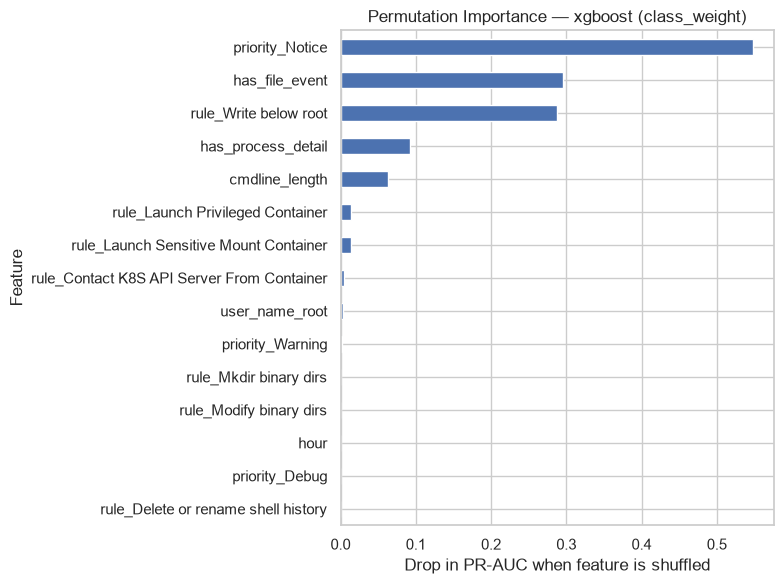

,Feature,Importance
8,rule_Delete or rename shell history,0.000122
1,priority_Debug,0.000129
46,hour,0.000203
13,rule_Modify binary dirs,0.001124
12,rule_Mkdir binary dirs,0.001189
4,priority_Warning,0.001457
38,user_name_root,0.003049
5,rule_Contact K8S API Server From Container,0.004174
11,rule_Launch Sensitive Mount Container,0.014158
10,rule_Launch Privileged Container,0.014281


In [16]:
permutation_result = permutation_importance(
    best_model,
    X_test_enc,
    y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=random_state,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test_enc.columns,
    "Importance": permutation_result.importances_mean
}).sort_values(by="Importance", ascending=False)

# Only keep the top 15 because showing all encoded columns would be unreadable
top_15 = permutation_df.head(15).sort_values(by="Importance", ascending=True)

top_15.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 6),
    legend=False
)

plt.title(f"Permutation Importance — {best_model_type} ({best_strategy})")
plt.xlabel("Drop in PR-AUC when feature is shuffled")
plt.tight_layout()
plt.show()

top_15

# permutation_df[permutation_df["Feature"].str.contains("mitre_tactic")]

### Summary of Permutation Importance

This shows the model depended on some features more.

**Most important features:**
- **`priority_Notice`**: by far the strongest signal (PR-AUC drop ≈ **0.55**)
- **`has_file_event`**: second most important (drop ≈ **0.30**)
- **`rule_Write below root`**: third (drop ≈ **0.29**)

The model leans heavily on a small set of features, especially **`priority_Notice`**, **`has_file_event`**, and **`rule_Write below root`**, to separate attacks from normal alerts.

## Cross-validation

On looking at Lab 4's cross-validation method (`KFold` + `cross_val_score`), I decided to use `StratifiedKFold` instead of plain `KFold`, since attacks are only 0.79% of the data and a random fold could otherwise end up with very few or zero attacks. I score with PR-AUC `average_precision` instead of accuracy, for the same reason discussed above comment.


Links that helped me:
(Stackoverflow: StratifiedKfold vs K-fold)[https://stackoverflow.com/questions/65318931/stratifiedkfold-vs-kfold-in-scikit-learn]
(scikit-learn: StratifiedKfold)[https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html]

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

combos_to_check = [
    (XGBOOST, CLASS_WEIGHT),
    (RANDOM_FOREST, CLASS_WEIGHT),
    (LOGISTIC_REGRESSION, CLASS_WEIGHT),
]

cv_results = []
for model_type, strategy in combos_to_check:
    model = build_model(model_type, strategy)
    scores = cross_val_score(model, X_train_enc, y_train, cv=skf, scoring="average_precision")
    print(f"{model_type} ({strategy}): PR-AUC = {round(scores.mean(), 4)} (+/- {round(scores.std(), 4)})")
    cv_results.append({
        "model": model_type,
        "strategy": strategy,
        "mean_pr_auc": scores.mean(),
        "std_pr_auc": scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

xgboost (class_weight): PR-AUC = 0.991 (+/- 0.007)
random_forest (class_weight): PR-AUC = 0.9904 (+/- 0.0075)
logistic_regression (class_weight): PR-AUC = 0.9801 (+/- 0.0125)


,model,strategy,mean_pr_auc,std_pr_auc
0,xgboost,class_weight,0.990962,0.007006
1,random_forest,class_weight,0.990435,0.007521
2,logistic_regression,class_weight,0.980054,0.012538


### Summary of Cross-Validation Results

This shows the best models are **stable**, not just good on one train/test split. The data is split into **5 folds** with `StratifiedKFold`, so each fold keeps the same attack/normal ratio, and each model is scored using **PR-AUC**.

All three models perform very well and consistently across folds. **XGBoost** and **Random Forest** are nearly identical and slightly ahead of **Logistic Regression**. The low standard deviations mean the results are **reliable**, not just a lucky split.

## Hyperparameter tuning

Using Lab 7's method (`GridSearchCV`). I only tune the single best combination (XGBoost + class_weight) rather than all 12, because tuning
every combination would multiply training time by a large factor for comparisons that were already ruled out by PR-AUC. This does not replace `best_model`, it's a separate check on whether tuning could improve on the already-selected best combination.

In [18]:
# A small, deliberately modest grid. This is a check on whether tuning
# helps, not an exhaustive search
parameters = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [100, 200],
}

xgb_for_tuning = build_model(XGBOOST, CLASS_WEIGHT)

grid_search = GridSearchCV(
    estimator=xgb_for_tuning,
    param_grid=parameters,
    scoring="average_precision",
    cv=5,
    verbose=0,
)

grid_search.fit(X_train_enc, y_train)

original_pr_auc = average_precision_score(y_test, best_model.predict_proba(X_test_enc)[:, 1])

print(f"Original best_model PR-AUC on test set: {round(original_pr_auc, 4)}")
print(f"Tuned model PR-AUC on test set: {round(grid_search.score(X_test_enc, y_test), 4)}")

Original best_model PR-AUC on test set: 0.991
Tuned model PR-AUC on test set: 0.9913


The tuned model's test PR-AUC (0.9913) is only 0.0003 higher than the original `best_model`'s (0.9910) which is well within the fold-to-fold variation already measured in cross-validation (+/- 0.0070). This suggests the default XGBoost hyperparameters were already close to optimal for this data, and tuning did not produce a meaningful improvement.

## Simple Latency calculation

The module guide mentions detection latency. This project is **offline** alert triage and not real-time, so I only timed how long the **best model** (XGBoost + class_weight) takes to score the test set once features are already encoded.

In [19]:
import time

start = time.time()
best_model.predict_proba(X_test_enc)
elapsed = time.time() - start

n_test = len(X_test_enc)
ms_per_alert = elapsed / n_test * 1000

print(f"Best model ({best_model_type} + {best_strategy})")
print(f"Scored {n_test:,} test alerts in {round(elapsed, 3)} seconds")
print(f"About {round(ms_per_alert, 3)} ms per alert (offline batch only)")

Best model (xgboost + class_weight)
Scored 35,330 test alerts in 0.011 seconds
About 0.0 ms per alert (offline batch only)


## Save results and the best model
I ranked the models based on the output from the `Comparison Table` which indicated that:
- Best balancing strategy for each models for my dataset was `class_weight`
- Best  Model was `XGBoost` index 0
- Second Best was `Random Forest` index 2
- Third Best was `Logistic Regression` index 7

In [ ]:
import joblib
import os

os.makedirs("./data", exist_ok=True)
os.makedirs("./models", exist_ok=True)
os.makedirs("./encoder", exist_ok=True)

# Comparison table, CV results, permutation importance saved
results_df.to_csv("./data/model_comparison_results.csv", index=False)
cv_results_df.to_csv("./data/cv_results.csv", index=False)
permutation_df.to_csv("./data/permutation_importance.csv", index=False)
print("Saved comparison table, CV results, and permutation importance.")

# Encoder saved
joblib.dump(encoder, "./encoder/onehot_encoder.joblib")
print("Saved comparison table and encoder.")

# Best model Saved
joblib.dump(best_model, f"./models/{best_model_type}.joblib")
print(f"Best model: {best_model_type} ({best_strategy}) - PR-AUC = {round(results_df.iloc[0]['pr_auc'], 4)}")

# 2nd-best model extracted and saved
second_best_model_type, second_best_strategy = results_df.iloc[2][["model", "strategy"]]
second_best_model = trained_models[(second_best_model_type, second_best_strategy)]
joblib.dump(second_best_model, f"./models/{second_best_model_type}.joblib")
print(f"2nd best: {second_best_model_type} ({second_best_strategy}) - PR-AUC = {round(results_df.iloc[2]['pr_auc'], 4)}")

# 3rd-best model extracted and saved
third_best_model_type, third_best_strategy = results_df.iloc[7][["model", "strategy"]]
third_best_model = trained_models[(third_best_model_type, third_best_strategy)]
joblib.dump(third_best_model, f"./models/{third_best_model_type}.joblib")
print(f"3rd best: {third_best_model_type} ({third_best_strategy}) - PR-AUC = {round(results_df.iloc[7]['pr_auc'], 4)}")

Saved comparison table, CV results, and permutation importance.
Saved comparison table and encoder.
Best model: xgboost (class_weight) - PR-AUC = 0.991
2nd best: random_forest (class_weight) - PR-AUC = 0.9904
3rd best: logistic_regression (class_weight) - PR-AUC = 0.9848
